In [1]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

In [2]:
from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import pathlib
FIGDIR = pathlib.Path("figs_tesis"); FIGDIR.mkdir(exist_ok=True)

In [3]:
save_path = "/Users/niaggar/Results"
data = [
    ("0000_radius_0.02", r"20 nm"),
    ("0001_radius_0.04", r"35 nm"),
    ("0002_radius_0.06", r"55 nm"),
    ("0003_radius_0.07", r"75 nm"),
    ("0004_radius_0.17", r"175 nm")
]



In [4]:
WHICH = "coherent"    # "coherent" | "incoherent" | "enhancement"
CMAP  = "jet"
R_MAX_MRAD = None     # None = todo theta; o p.ej. 17.0 para recortar el borde

def polar_map(ax, prof, channel, which=WHICH, cmap=CMAP, robust=True):
    Z = prof.enhancement[channel]          # (n_theta, n_phi)
    theta = prof.theta * 1e3                     # mrad (radio)
    n_theta, n_phi = Z.shape

    # bordes de celda -> pcolormesh flat (X,Y una celda mas grande que Z)
    dth = np.diff(theta)
    th_edges = np.concatenate([[theta[0] - dth[0] / 2], theta[:-1] + dth / 2, [theta[-1] + dth[-1] / 2]])
    phi_edges = np.linspace(0.0, 2 * np.pi, n_phi + 1)   # borde izq. de cada bin

    PHI, TH = np.meshgrid(phi_edges, th_edges)

    if robust:
        vmin, vmax = np.percentile(Z, [2, 98])   # recorta colas de ruido
    else:
        vmin = vmax = None

    pc = ax.pcolormesh(PHI, TH, Z, cmap=cmap, shading="flat", vmin=vmin, vmax=vmax)

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    if R_MAX_MRAD is not None:
        ax.set_ylim(0, R_MAX_MRAD)
    ax.set_rlabel_position(135)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)
    return pc

# Linear Polarization study of RGD particles

In [5]:
folder = "study_rgd_particles__PLIN"
sweep_data = load_sweep(folder, base_path=Path(save_path))

data_keys = list(sweep_data.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")


Loaded 5 datasets: ['0004_radius_0.17', '0003_radius_0.07', '0001_radius_0.04', '0002_radius_0.06', '0000_radius_0.02']


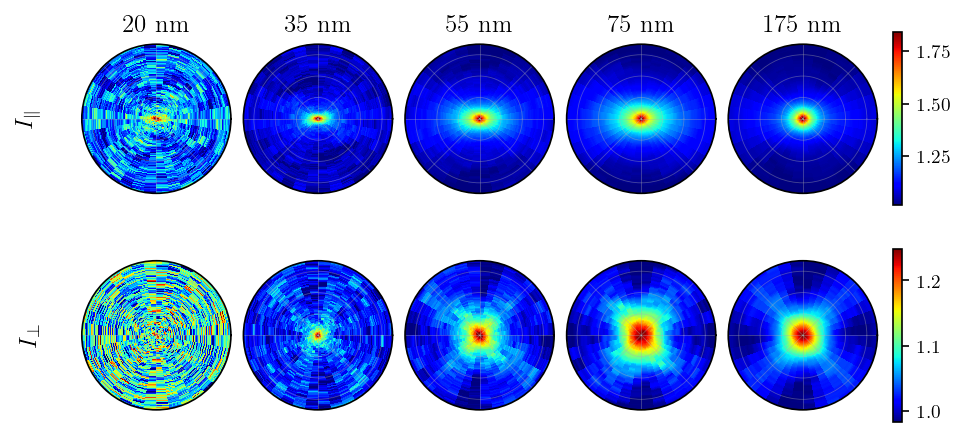

In [6]:
apply(width_frac=1.0)

fig, axes = plt.subplots(
    2, 5, figsize=(TEXTWIDTH_IN, 0.46*TEXTWIDTH_IN),
    subplot_kw={"projection": "polar"},
)

ROW_SPECS = [
    ("co",    r"$I_\parallel$"),
    ("cross", r"$I_\perp$"),
]

for i, (channel, sym) in enumerate(ROW_SPECS):
    row_axes = axes[i, :]
    for ax, (ch, title) in zip(row_axes, data):
        prof = cbs_profiles(sweep_data[ch].processed_cbs("farfield_cbs"),
                            basis=linear, time_index=0, reduce=keep)
        pc = polar_map(ax, prof, channel)

        if i == 0:                       # títulos de columna solo arriba
            ax.set_title(title, pad=6)

        ax.set_xticklabels([])           # sin etiquetas angulares
        ax.set_yticklabels([])           # sin números radiales por panel
        ax.grid(True, lw=0.4, alpha=0.4)

    # colorbar por fila (co y cross tienen rangos distintos: correcto)
    cb = fig.colorbar(pc, ax=row_axes, shrink=0.85, pad=0.02, location="right")
    cb.ax.tick_params(labelsize=9)

    # etiqueta de canal a la izquierda de la fila
    row_axes[0].text(-0.28, 0.5, sym, transform=row_axes[0].transAxes, ha="right", va="center", rotation=90)

fig.savefig(FIGDIR / "polar_maps_rgd_lin.png", dpi=300)

## Linear Polarization ZOOM

In [7]:
folder_zoom = "study_rgd_particles_ZOOM__PLIN"
sweep_data_zoom = load_sweep(folder_zoom, base_path=Path(save_path))

data_keys_zoom = list(sweep_data_zoom.keys())
print(f"Loaded {len(data_keys_zoom)} datasets: {data_keys_zoom}")


Loaded 5 datasets: ['0004_radius_0.17', '0003_radius_0.07', '0001_radius_0.04', '0002_radius_0.06', '0000_radius_0.02']


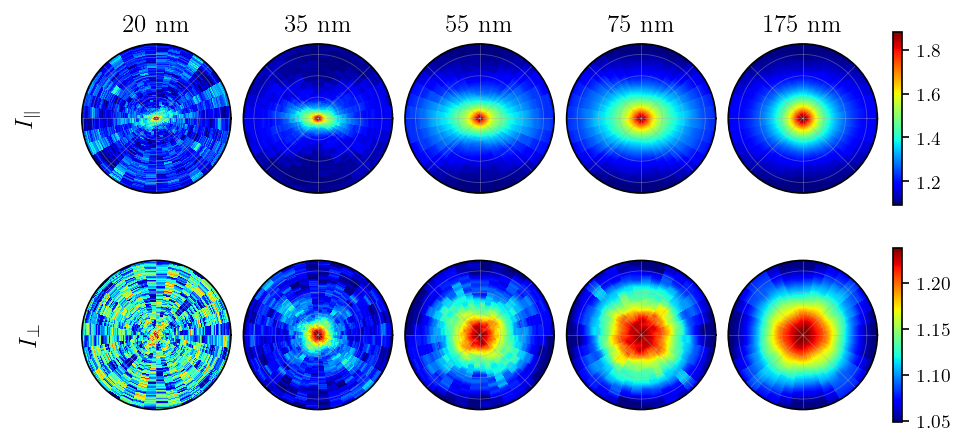

In [8]:
apply(width_frac=1.0)

fig, axes = plt.subplots(
    2, 5, figsize=(TEXTWIDTH_IN, 0.46*TEXTWIDTH_IN),
    subplot_kw={"projection": "polar"},
)

ROW_SPECS = [
    ("co",    r"$I_\parallel$"),
    ("cross", r"$I_\perp$"),
]

for i, (channel, sym) in enumerate(ROW_SPECS):
    row_axes = axes[i, :]
    for ax, (ch, title) in zip(row_axes, data):
        prof = cbs_profiles(sweep_data_zoom[ch].processed_cbs("farfield_cbs"),
                            basis=linear, time_index=0, reduce=keep)
        pc = polar_map(ax, prof, channel)

        if i == 0:                       # títulos de columna solo arriba
            ax.set_title(title, pad=6)

        ax.set_xticklabels([])           # sin etiquetas angulares
        ax.set_yticklabels([])           # sin números radiales por panel
        ax.grid(True, lw=0.4, alpha=0.4)

    # colorbar por fila (co y cross tienen rangos distintos: correcto)
    cb = fig.colorbar(pc, ax=row_axes, shrink=0.85, pad=0.02, location="right")
    cb.ax.tick_params(labelsize=9)

    # etiqueta de canal a la izquierda de la fila
    row_axes[0].text(-0.28, 0.5, sym, transform=row_axes[0].transAxes, ha="right", va="center", rotation=90)

fig.savefig(FIGDIR / "polar_maps_rgd_lin_ZOOM.png", dpi=300)

# Circular Polarization study of RGD particles

In [9]:
folder_circular = "study_rgd_particles__PCIR"
sweep_data_circular = load_sweep(folder_circular, base_path=Path(save_path))

data_keys_circular = list(sweep_data_circular.keys())
print(f"Loaded {len(data_keys_circular)} datasets: {data_keys_circular}")

Loaded 5 datasets: ['0004_radius_0.17', '0003_radius_0.07', '0001_radius_0.04', '0002_radius_0.06', '0000_radius_0.02']


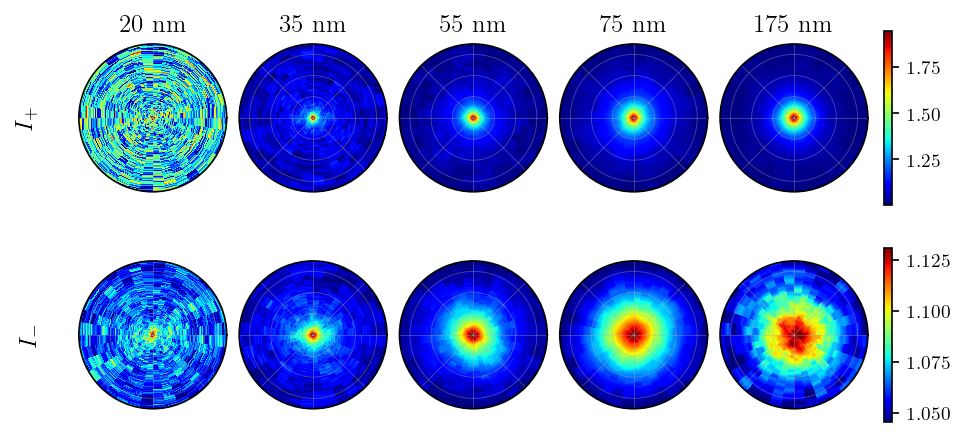

In [10]:
apply(width_frac=1.0)

fig, axes = plt.subplots(
    2, 5, figsize=(TEXTWIDTH_IN, 0.46*TEXTWIDTH_IN),
    subplot_kw={"projection": "polar"},
)

ROW_SPECS = [
    ("co",    r"$I_+$"),
    ("cross", r"$I_-$"),
]

for i, (channel, sym) in enumerate(ROW_SPECS):
    row_axes = axes[i, :]
    for ax, (ch, title) in zip(row_axes, data):
        prof = cbs_profiles(sweep_data_circular[ch].processed_cbs("farfield_cbs"),
                            basis=circular, time_index=0, reduce=keep)
        pc = polar_map(ax, prof, channel)

        if i == 0:                       # títulos de columna solo arriba
            ax.set_title(title, pad=6)

        ax.set_xticklabels([])           # sin etiquetas angulares
        ax.set_yticklabels([])           # sin números radiales por panel
        ax.grid(True, lw=0.4, alpha=0.4)

    # colorbar por fila (co y cross tienen rangos distintos: correcto)
    cb = fig.colorbar(pc, ax=row_axes, shrink=0.85, pad=0.02, location="right")
    cb.ax.tick_params(labelsize=9)

    # etiqueta de canal a la izquierda de la fila
    row_axes[0].text(-0.28, 0.5, sym, transform=row_axes[0].transAxes, ha="right", va="center", rotation=90)

fig.savefig(FIGDIR / "polar_maps_rgd_circ.png", dpi=300)